# Recordings outside the limits of agreement

The per-recording Bland-Altman (`signal_durations.png`) compares the median span length each side
calls per radar signal. This notebook takes the points outside its 95% limits, draws their windows,
and tests two suspects: how the model uses `unknown`, and how spans next to `unknown` are counted.

Labels are human, stop merged into exhale, so scores measure agreement with the labellers.

In [1]:
import sys
from pathlib import Path


def repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'phase').is_dir():
            return candidate
    raise RuntimeError(f'no inhale-exhale-training checkout at or above {start}')


REPO = repo_root(Path.cwd().resolve())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

In [2]:
import numpy as np
import pandas as pd
from IPython.display import Image, display

import report_folds as rf
from phase import durations, figures
from phase.building import shard_path
from phase.decode import decode
from phase.labels import EXHALE, PHASES, STOP, UNKNOWN, targets_to_spans, touches_edge
from phase.metrics import match_spans

RUN = REPO / 'outputs/2026-09-27/10-30-49'          # 3-class, stop merged into exhale
BASELINE = REPO / 'outputs/2026-08-27/10-23-34'     # 4-class, same windows and splits
OUT = REPO / 'out' / 'recording_outliers'
OUT.mkdir(parents=True, exist_ok=True)

folds = rf.load_run(RUN)
settings = rf.settings_of(RUN, folds, None, None)
COST, MIN_DURATION = settings['cost'], settings['min_duration']
IOU, PLOT = settings['event_iou'], settings['plot_cfg']
ensemble, windows = rf.ensemble_of(folds)
CLASSES = rf.classes_in(windows)
COLUMNS = durations.columns_for(CLASSES)
items = rf.duration_items(RUN, ensemble, windows, COST, MIN_DURATION)
traces = rf.traces_for(RUN, ensemble['window_id'], ensemble['env'])
print(f'{len(items)} test windows, classes {CLASSES}')

5 folds, 228 test windows each, 15 patients - window ids identical
labels.source = human, stop_as_exhale = True, switch_penalty = 2.0, enforce_min = False, transition table = {'unknown': ['inhale', 'exhale'], 'inhale': ['exhale', 'unknown'], 'exhale': ['inhale', 'unknown']}


228 test windows, classes ('unknown', 'inhale', 'exhale')


## The points outside the limits

In [3]:
medians = durations.signal_medians(items)
stats = durations.signal_agreement(medians, COLUMNS)
usable = medians[medians[durations.USABLE]]

limits = stats[['loa_low', 'loa_high']]
outside = usable.join(limits, on='phase')
outside = outside[(outside[durations.ERROR] < outside.loa_low)
                  | (outside[durations.ERROR] > outside.loa_high)]
OUTLIERS = set(zip(outside.env, outside.signal))
print(f'{len(outside)} signal-phase points outside the limits, from {len(OUTLIERS)} of '
      f'{usable[["env", "signal"]].drop_duplicates().shape[0]} recordings')
outside[['patient', 'signal', 'phase', 'median_labelled', 'median_model', 'spans_labelled',
         'spans_model', durations.ERROR]].round(2)

10 signal-phase points outside the limits, from 8 of 109 recordings


,patient,signal,phase,median_labelled,median_model,spans_labelled,spans_model,error_sec
17,SL0059,1582658,inhale,0.85,1.10,4,4,0.25
70,SL0063,1801049,exhale/inhale,1.35,2.08,4,4,0.73
71,SL0063,1801049,inhale,1.70,1.25,4,4,-0.45
107,SL0065,1906849,inhale,1.30,1.60,5,5,0.30
144,RM-005,17317550,exhale,2.15,1.55,6,6,-0.60
162,bs-002,17456851,exhale,3.65,1.70,8,7,-1.95
163,bs-002,17456851,exhale/inhale,3.04,1.31,7,7,-1.73
167,RM-005,17495769,inhale,2.10,1.80,13,14,-0.30
217,bs-001,17726713,exhale/inhale,4.67,3.86,5,6,-0.81
330,RM-005,18641345,exhale,2.40,1.85,4,4,-0.55


## What those recordings look like

Per window: accuracy, and how much of it each side calls `unknown`.

In [4]:
def window_row(item):
    labelled, called = item[durations.LABEL], item[durations.MODEL]
    return {'env': item['env'], 'signal': item['signal'], 'window_id': item['window_id'],
            'patient': item['patient'], 'outlier': (item['env'], item['signal']) in OUTLIERS,
            'accuracy': figures.score(called, labelled),
            'unknown_labelled': float((labelled == UNKNOWN).mean()),
            'unknown_model': float((called == UNKNOWN).mean())}


per_window = pd.DataFrame([window_row(item) for item in items])
print(per_window.groupby('outlier')[['accuracy', 'unknown_labelled', 'unknown_model']]
      .mean().round(2))
per_window[per_window.outlier].sort_values('accuracy').round(2)

         accuracy  unknown_labelled  unknown_model
outlier                                           
False        0.91              0.25           0.28
True         0.80              0.10           0.25


,env,signal,window_id,patient,outlier,accuracy,unknown_labelled,unknown_model
81,ds_prod,17317550,1861,RM-005,True,0.42,0.00,0.56
80,ds_prod,17317550,1860,RM-005,True,0.47,0.14,0.57
95,ds_prod,17456851,257,bs-002,True,0.57,0.00,0.42
96,ds_prod,17456851,262,bs-002,True,0.60,0.04,0.42
18,ds_algo,1582658,1189,SL0059,True,0.88,0.56,0.49
214,ds_prod,18641345,1896,RM-005,True,0.90,0.44,0.53
39,ds_algo,1801049,1339,SL0063,True,0.92,0.00,0.00
99,ds_prod,17495769,1868,RM-005,True,0.94,0.00,0.00
134,ds_prod,17726713,197,bs-001,True,0.95,0.00,0.02
58,ds_algo,1906849,1468,SL0065,True,0.96,0.00,0.00


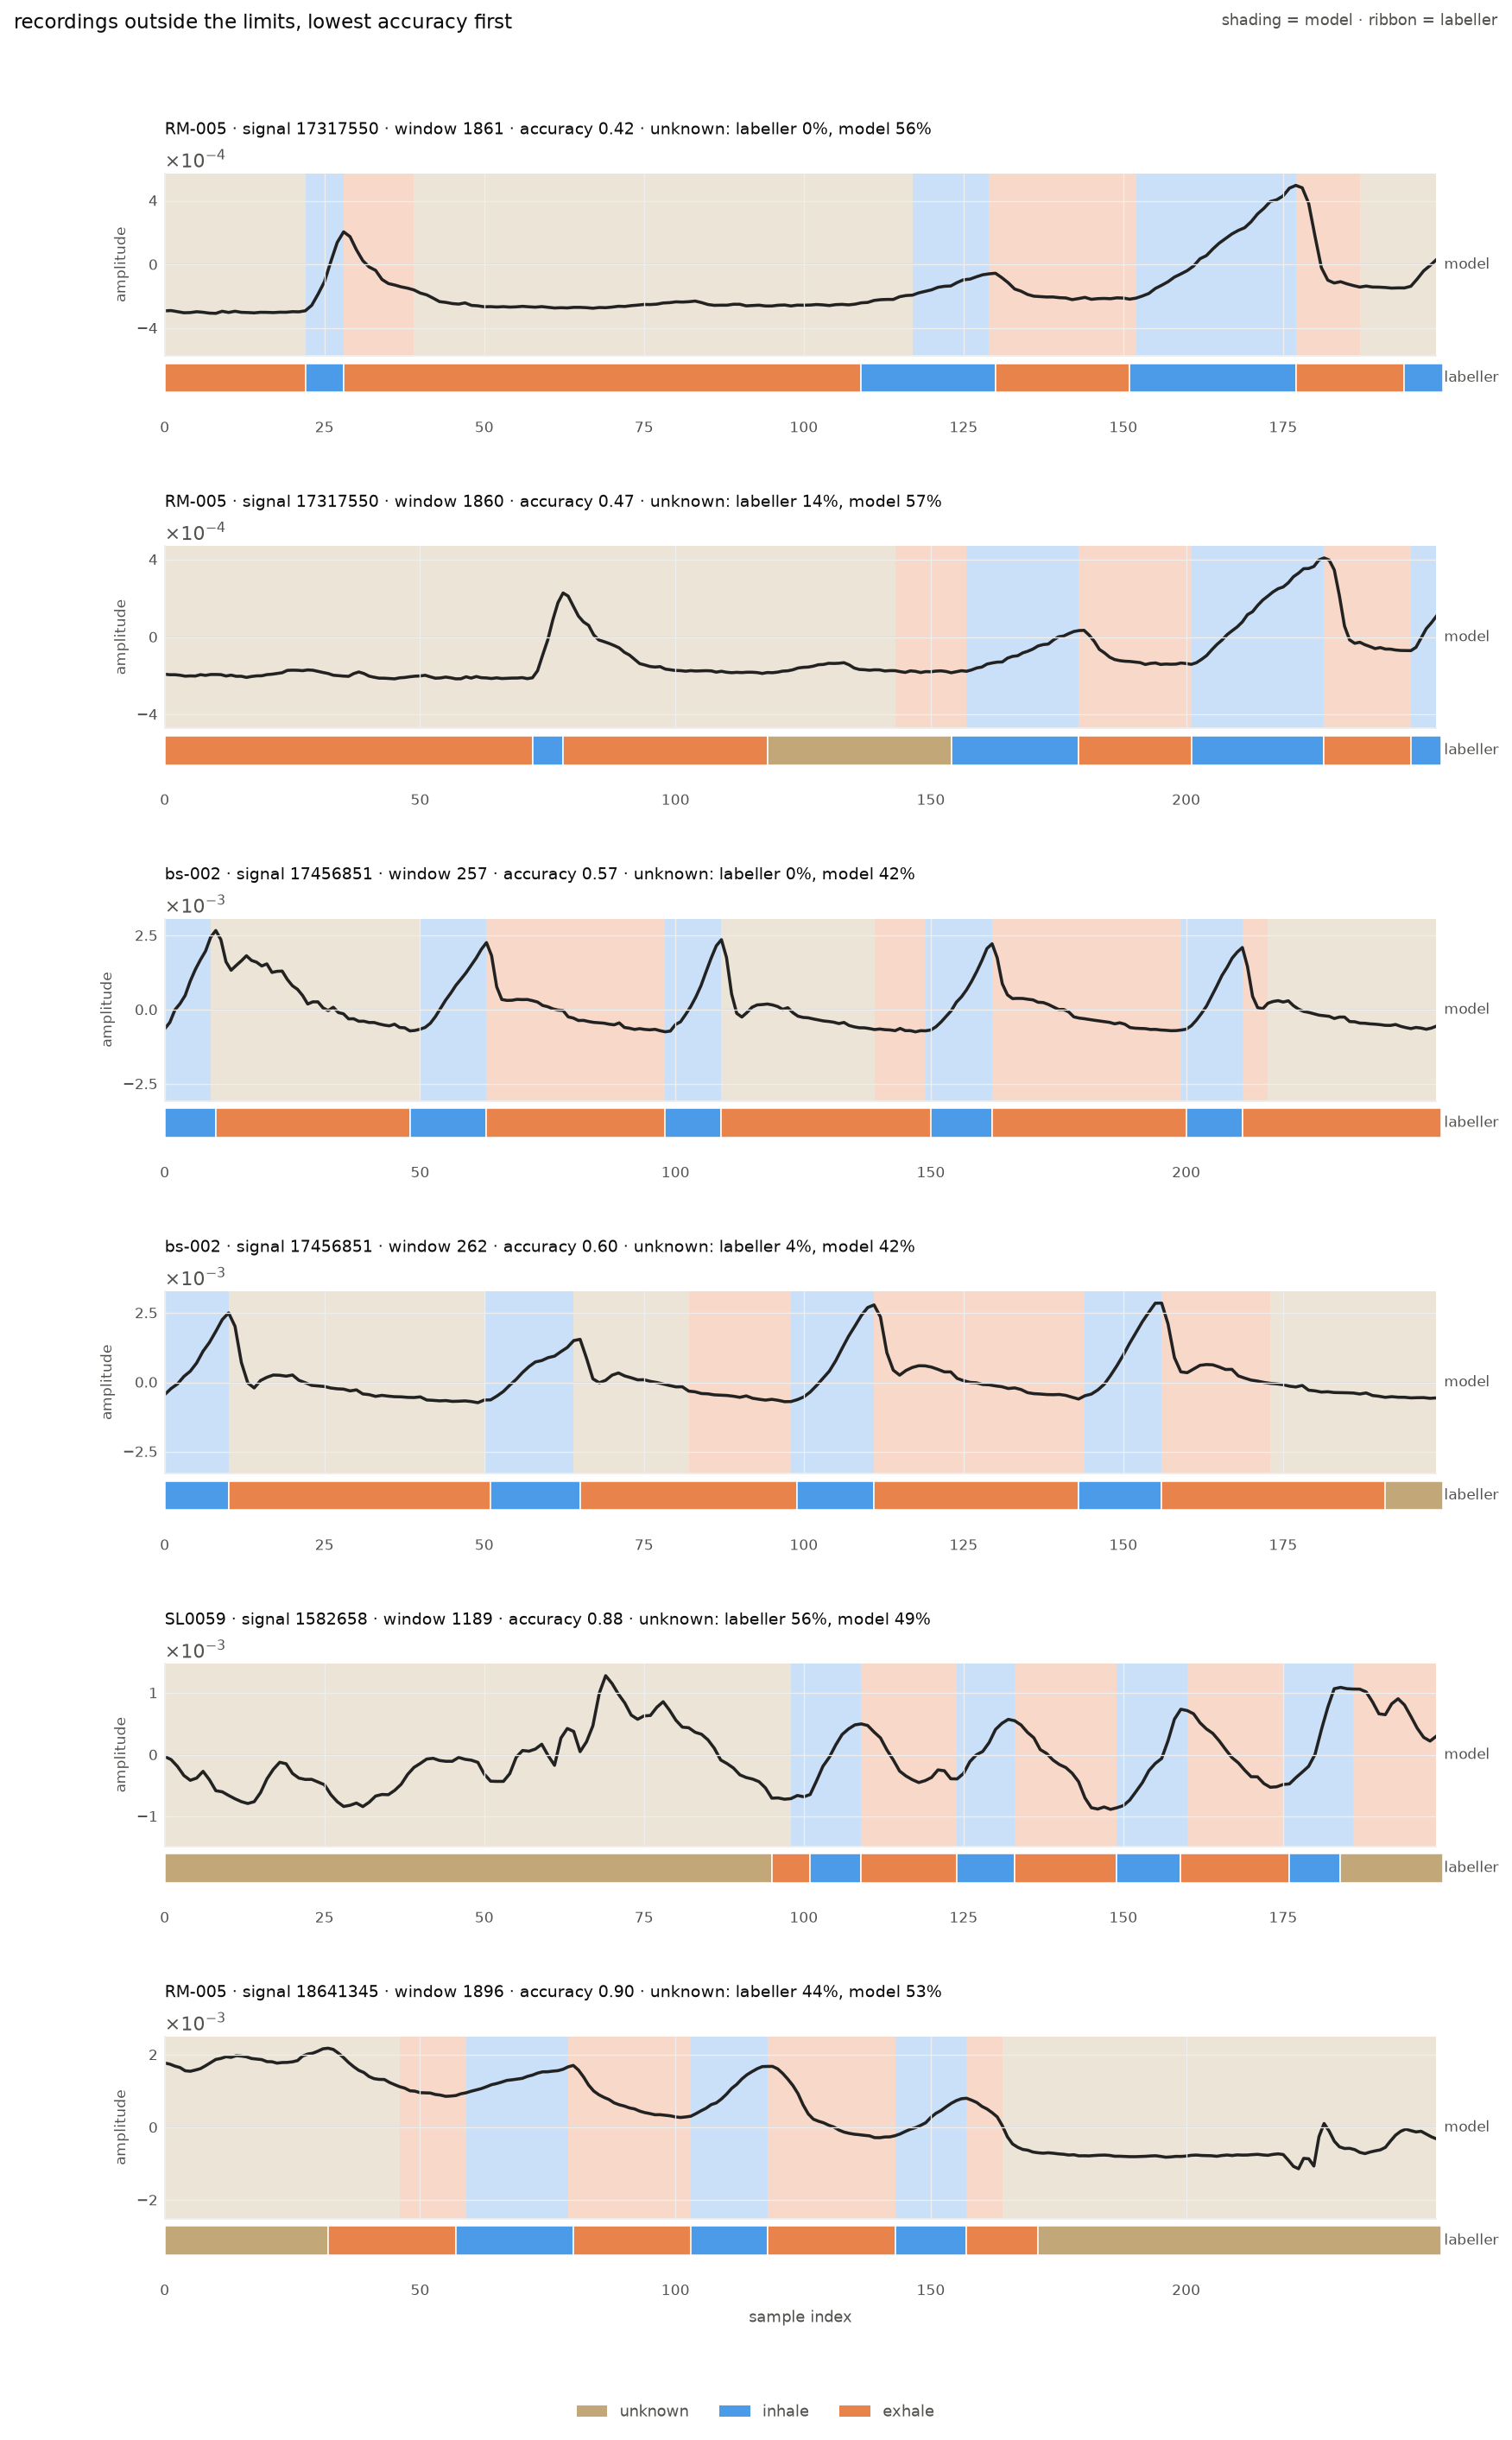

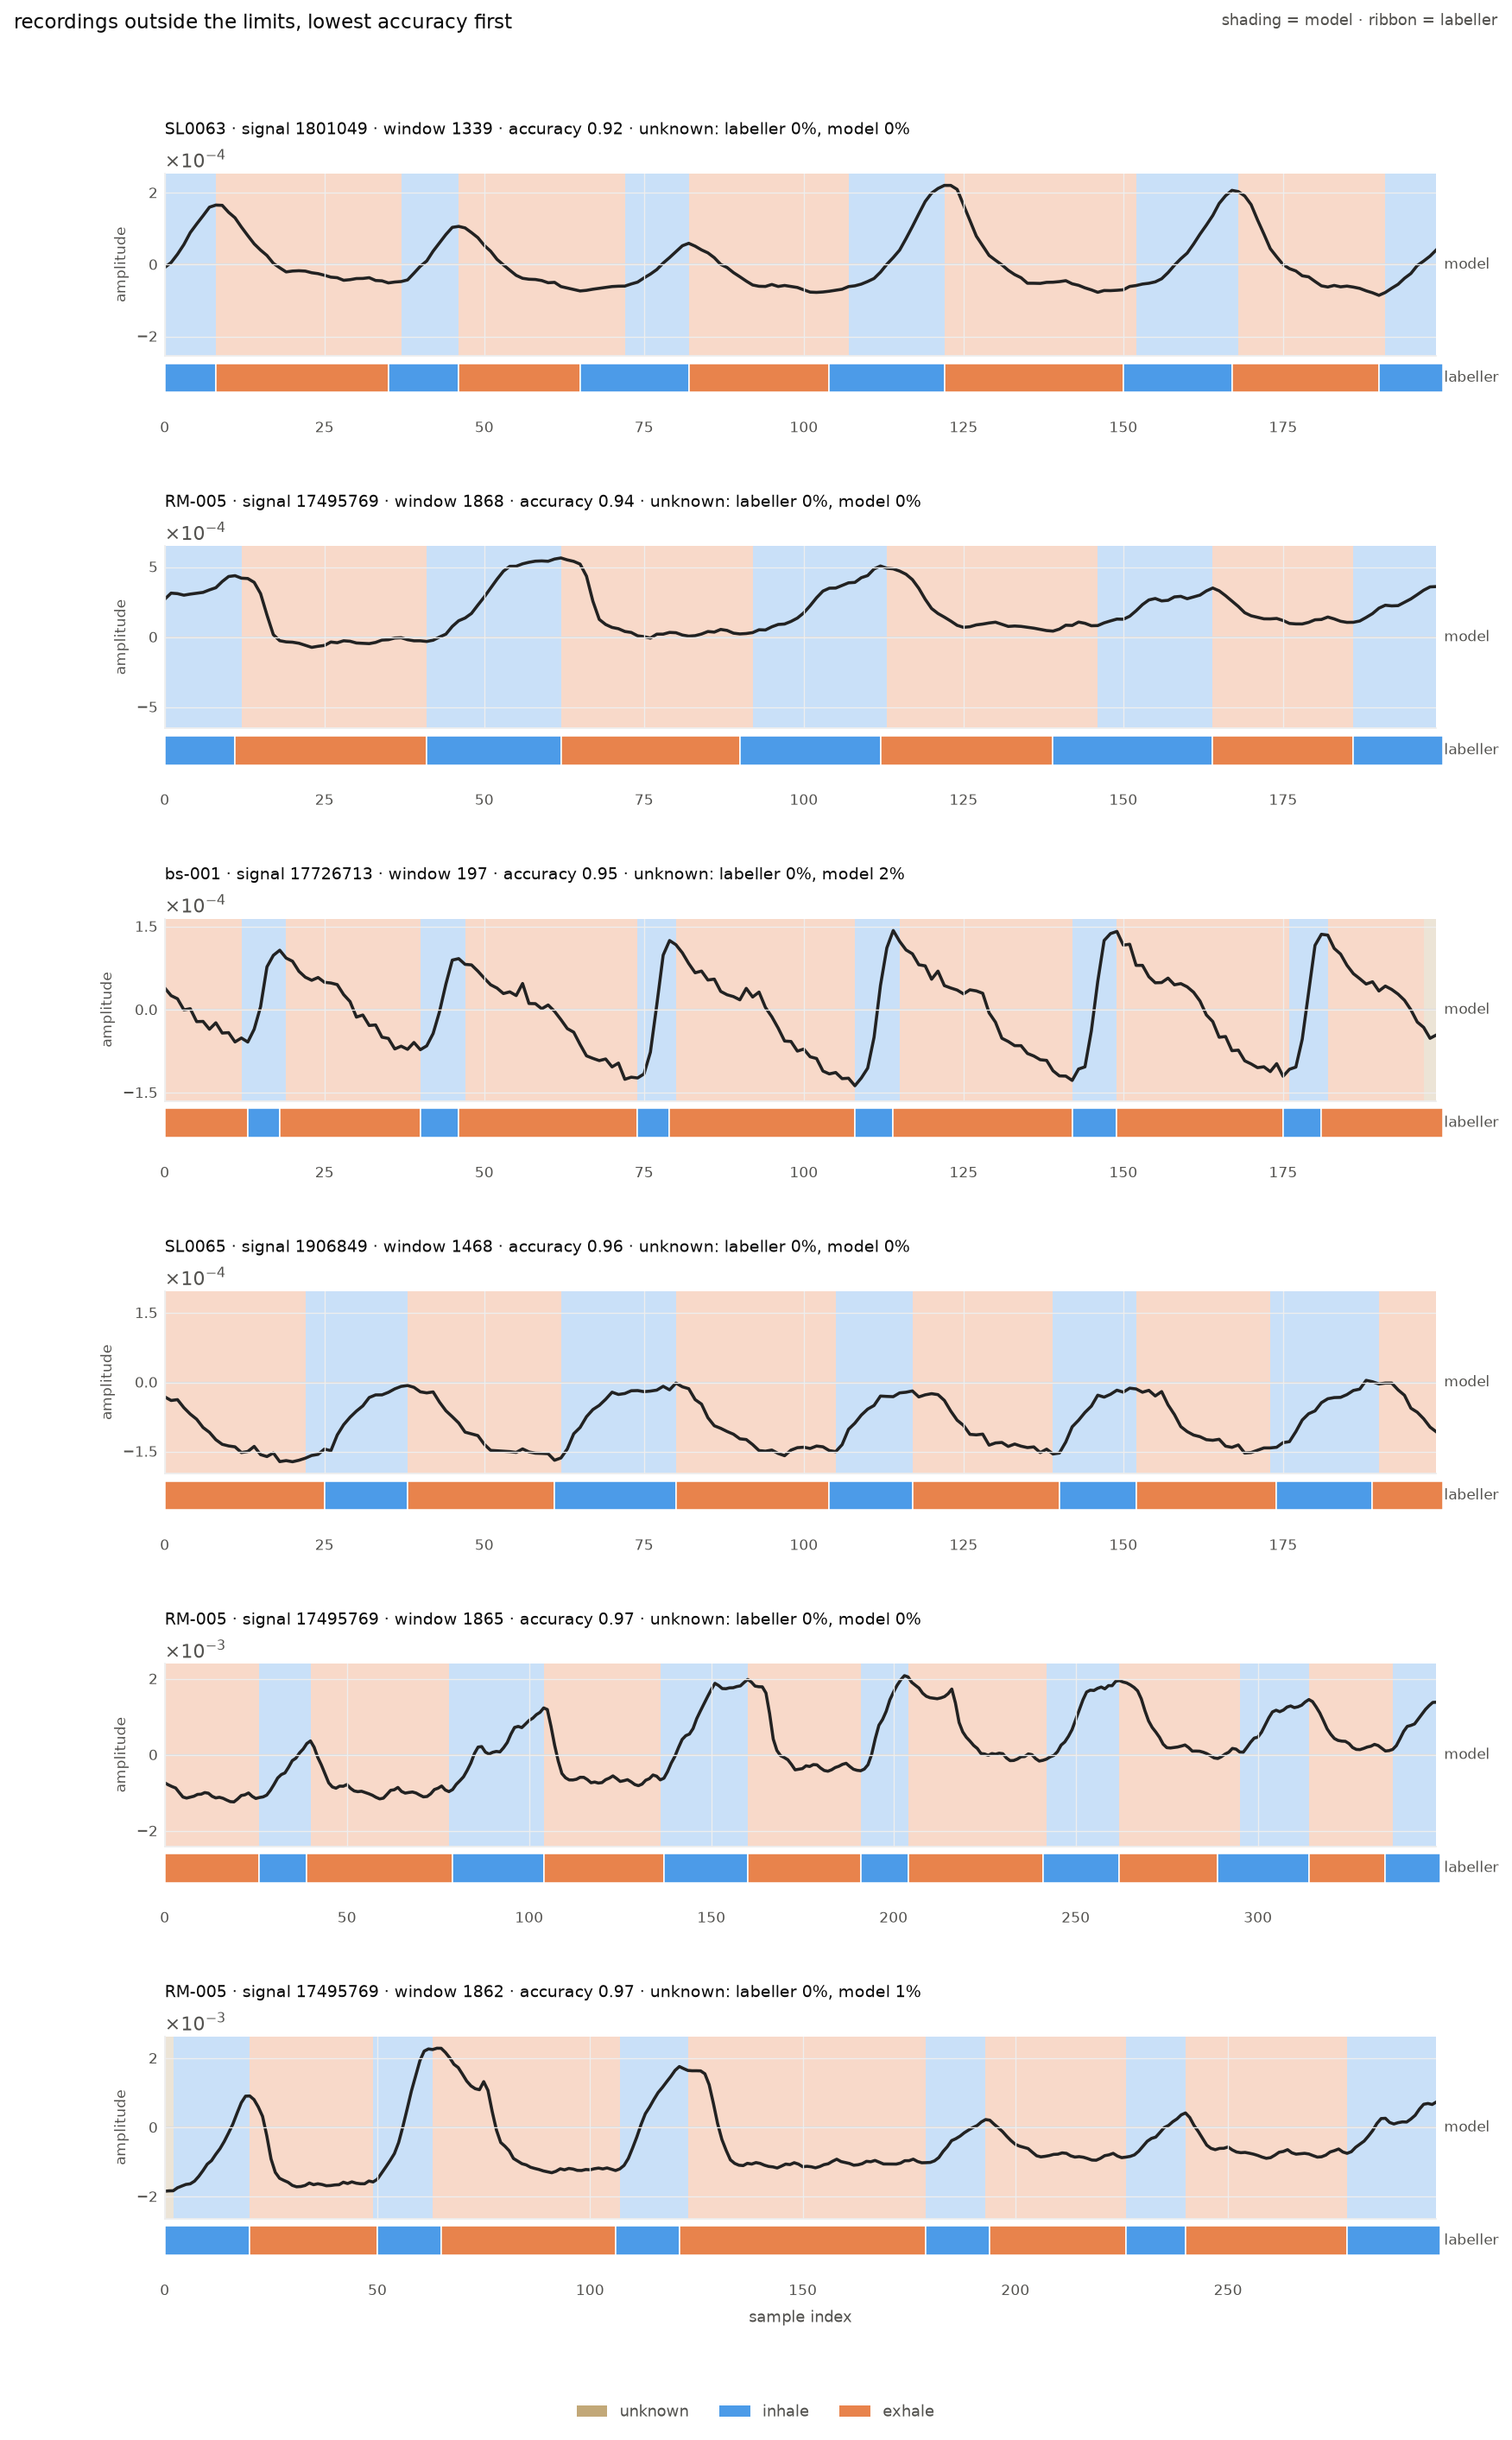

In [5]:
def draw(chosen: pd.DataFrame, name: str, heading: str) -> Path:
    by_key = {(i['env'], i['window_id']): i for i in items}
    panels = []
    for row in chosen.itertuples():
        item = by_key[(row.env, row.window_id)]
        panels.append({
            'values': traces[(row.env, int(row.window_id))]['values'],
            'reference': item[durations.LABEL], 'prediction': item[durations.MODEL],
            'fps': item['fps'],
            'title': (f'{row.patient} · signal {row.signal} · window {row.window_id} · '
                      f'accuracy {row.accuracy:.2f} · unknown: labeller {row.unknown_labelled:.0%}, '
                      f'model {row.unknown_model:.0%}')})
    return figures.plot_windows(panels, OUT / name, heading, 'labeller', PLOT, classes=CLASSES)


chosen = per_window[per_window.outlier].sort_values('accuracy')
for page in range(0, len(chosen), 6):
    display(Image(filename=str(draw(chosen.iloc[page:page + 6], f'outliers_{page // 6}.png',
                                    'recordings outside the limits, lowest accuracy first'))))

## Is the pause what the model calls unknown?

In the worst recordings the model calls `unknown` over a flat stretch the labeller called exhale.
Those stretches were `stop` before the merge, and each shard still holds the labels as drawn, so
the question can be asked directly - and asked of the 4-class baseline too, to see whether the
merge caused it.

In [6]:
provenance = rf.provenance_for(RUN, ensemble['window_id'], ensemble['env'])
dataset = rf.dataset_of(RUN)


def drawn_labels(index: int) -> np.ndarray:
    row = provenance[(str(ensemble['env'][index]), int(ensemble['window_id'][index]))]
    with np.load(shard_path(dataset, row['shard'])) as stored:
        offsets = stored['offsets']
        return stored['targets_drawn'][offsets[row['position']]:offsets[row['position'] + 1]]


def decoded(runs: Path) -> list[np.ndarray]:
    run_folds = rf.load_run(runs)
    run_settings = rf.settings_of(runs, run_folds, None, None)
    _, run_windows = rf.ensemble_of(run_folds)
    return [decode(logits, run_settings['cost'], run_settings['min_duration'])
            for logits, _ in run_windows]


drawn = [drawn_labels(i).astype(int) for i in range(len(windows))]
merged_model, baseline_model = decoded(RUN), decoded(BASELINE)
DRAWN = np.concatenate(drawn)


def called_on(mask: np.ndarray, prediction: list[np.ndarray], classes) -> dict:
    counts = np.bincount(np.concatenate(prediction)[mask], minlength=len(classes))
    return {name: round(counts[k] / mask.sum(), 3) for k, name in enumerate(classes)}


pd.DataFrame({
    '3-class on pause': called_on(DRAWN == STOP, merged_model, CLASSES),
    '3-class on exhale': called_on(DRAWN == EXHALE, merged_model, CLASSES),
    '4-class on pause': called_on(DRAWN == STOP, baseline_model, PHASES),
    '4-class on exhale': called_on(DRAWN == EXHALE, baseline_model, PHASES),
}).T.fillna('')

5 folds, 228 test windows each, 15 patients - window ids identical
labels.source = human, stop_as_exhale = True, switch_penalty = 2.0, enforce_min = False, transition table = {'unknown': ['inhale', 'exhale'], 'inhale': ['exhale', 'unknown'], 'exhale': ['inhale', 'unknown']}
5 folds, 228 test windows each, 15 patients - window ids identical
labels.source = human, stop_as_exhale = False, switch_penalty = 2.0, enforce_min = False, transition table = {'unknown': ['inhale', 'exhale', 'stop'], 'inhale': ['exhale', 'unknown'], 'exhale': ['stop', 'inhale', 'unknown'], 'stop': ['inhale', 'unknown']}


,unknown,inhale,exhale,stop
3-class on pause,0.118,0.038,0.844,
3-class on exhale,0.071,0.017,0.912,
4-class on pause,0.113,0.026,0.047,0.814
4-class on exhale,0.071,0.011,0.802,0.115


By pause length - how often the 3-class model calls a labelled pause `unknown`:

In [7]:
rows = []
for labels, prediction in zip(drawn, merged_model):
    for span in targets_to_spans(labels):
        if span['phase'] == PHASES[STOP]:
            piece = prediction[span['start']:span['end']]
            rows.append({'seconds': (span['end'] - span['start']) / settings['fps'],
                         'called_unknown': float((piece == UNKNOWN).mean())})
pauses = pd.DataFrame(rows)
pauses['length'] = pd.cut(pauses.seconds, [0, 0.5, 1, 1.5, 2, 3, 20])
pauses.groupby('length', observed=True).agg(pauses=('seconds', 'size'),
                                            called_unknown=('called_unknown', 'mean')).round(2)

,pauses,called_unknown
length,,
"(0.0, 0.5]",368,0.05
"(0.5, 1.0]",266,0.07
"(1.0, 1.5]",154,0.12
"(1.5, 2.0]",54,0.09
"(2.0, 3.0]",24,0.31
"(3.0, 20.0]",9,0.33


## Reporting rules, decided from the prediction alone

At inference there is no labeller, so every rule reads only the model's output.

- **fill** - one pass over the prediction: a span beside a predicted `unknown` becomes `unknown`.
  Its end is where the model gave up, not where the breath ended. Applied **before** the edge rule,
  so an `unknown` at the window edge fills its neighbour too, and once, so it does not cascade.
- **window threshold** - drop a window whose raw prediction is more than `T` `unknown`.
- The existing edge rule then drops spans touching the window boundary.

**Scoring is paired.** A labelled breath is compared only where the model still reports: a labelled
span lying mostly under the model's (filled) `unknown` is set aside on both sides, and counted as
**not reported**. Without that, the model's surviving breaths are compared against all of the
labeller's breaths - two different sets - which biases the model's median and makes any rule look
worse or better for reasons that have nothing to do with it. Every table carries the share of
labelled breaths still reported, because a rule that drops hard breaths always looks better on the
breaths it keeps.

In [8]:
def fill_adjacent(prediction: np.ndarray) -> np.ndarray:
    spans = targets_to_spans(prediction)
    out = prediction.copy()
    for i, span in enumerate(spans):
        if span['phase'] == PHASES[UNKNOWN]:
            continue
        if any(0 <= j < len(spans) and spans[j]['phase'] == PHASES[UNKNOWN] for j in (i - 1, i + 1)):
            out[span['start']:span['end']] = UNKNOWN
    return out


def paired(item: dict) -> dict:
    """The labelled reference, set aside wherever the model reports nothing."""
    labels = item[durations.LABEL].copy()
    silent = item[durations.MODEL] == UNKNOWN
    for span in targets_to_spans(labels):
        if span['phase'] != PHASES[UNKNOWN] and silent[span['start']:span['end']].mean() > 0.5:
            labels[span['start']:span['end']] = UNKNOWN
    return {**item, durations.LABEL: labels}


def under_rules(source: list[dict], threshold=None, fill=True) -> list[dict]:
    kept = []
    for item in source:
        raw = item[durations.MODEL]
        if threshold is not None and (raw == UNKNOWN).mean() > threshold:
            continue
        kept.append(paired({**item, durations.MODEL: fill_adjacent(raw) if fill else raw}))
    return kept


def labelled_breaths(source: list[dict]) -> int:
    return sum(len(durations.interior_spans(i[durations.LABEL], p))
               for i in source for p in ('inhale', 'exhale'))

## Choosing the window threshold - on validation, not on the test set

The test set cannot choose its own threshold. Every fold's model predicts its own **validation**
windows, which it never trained on - 853 windows from 341 recordings, four times the test set. The
threshold is derived there and checked once on test.

In [9]:
from models.lightning_module import PhaseSegmenter
from phase.building import load_windows
from phase.splits import TEST, VAL, split_for
from train import test_predictions

CONTROL = REPO / 'outputs/2026-09-27/12-02-58'   # the recommended config, seeded
control_dataset = Path((CONTROL / 'fold_0' / 'dataset.txt').read_text().strip())
if not control_dataset.is_absolute():
    control_dataset = REPO / control_dataset
control_manifest = load_windows(control_dataset)


def fold_predictions(split: str) -> list[dict]:
    rows = []
    for fold in range(5):
        checkpoint = next((CONTROL / f'fold_{fold}' / 'checkpoints').glob('best-*.ckpt'))
        model = PhaseSegmenter.load_from_checkpoint(str(checkpoint), map_location='cpu').eval()
        for item in test_predictions(model, control_dataset, split_for(control_manifest, fold)[split]):
            row = item['row']
            rows.append({durations.LABEL: item['reference'], durations.MODEL: item['prediction'],
                         'fps': item['fps'], 'env': str(row['env']),
                         'window_id': int(row['RespirationWindowID']),
                         'signal': int(row['RadarSignalID']), 'patient': str(row['PatientID'])})
    return rows


validation = fold_predictions(VAL)
print(f'{len(validation)} validation windows, '
      f'{len({(r["env"], r["signal"]) for r in validation})} recordings')

853 validation windows, 341 recordings


In [10]:
def per_window(source: list[dict]) -> pd.DataFrame:
    """Per window: its raw predicted-unknown share, and the mean relative error of its matched breaths."""
    rows = []
    for item in source:
        raw = item[durations.MODEL]
        scored = paired({**item, durations.MODEL: fill_adjacent(raw)})
        errors, labelled = [], 0
        for phase in ('inhale', 'exhale'):
            reference = durations.interior_spans(item[durations.LABEL], phase)
            labelled += len(reference)
            for truth, called, _ in match_spans(durations.interior_spans(scored[durations.LABEL], phase),
                                                durations.interior_spans(scored[durations.MODEL], phase),
                                                IOU):
                length = truth['end'] - truth['start']
                errors.append(abs((called['end'] - called['start']) - length) / length)
        rows.append({'env': item['env'], 'signal': item['signal'],
                     'unknown': float((raw == UNKNOWN).mean()), 'labelled': labelled,
                     'matched': len(errors), 'error': float(np.mean(errors)) if errors else np.nan})
    return pd.DataFrame(rows)


val_windows = per_window(validation)
scored = val_windows.dropna(subset=['error']).copy()
scored['predicted unknown'] = pd.cut(scored.unknown, [-0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 1.0])
scored.groupby('predicted unknown', observed=True).agg(
    windows=('error', 'size'), breaths=('matched', 'sum'),
    mean_error=('error', 'mean'), median_error=('error', 'median')).round(3)

,windows,breaths,mean_error,median_error
predicted unknown,,,,
"(-0.001, 0.1]",502,4956,0.063,0.054
"(0.1, 0.2]",80,701,0.089,0.078
"(0.2, 0.3]",48,379,0.082,0.069
"(0.3, 0.4]",38,231,0.090,0.086
"(0.4, 0.5]",15,67,0.112,0.078
"(0.5, 0.6]",11,40,0.158,0.150
"(0.6, 1.0]",20,46,0.137,0.066


Error rises with the window's predicted-`unknown` share - but gradually. Is there a point where it
changes level? A single-changepoint fit (breath-weighted, no parameter), with a permutation test
and a bootstrap over recordings for its position:

In [11]:
def best_split(u, e, w, min_side=30):
    order = np.argsort(u)
    u, e, w = u[order], e[order], w[order]
    best_sse, best_at = np.inf, None
    for k in range(min_side, len(u) - min_side):
        if u[k] == u[k - 1]:
            continue
        sse = sum(np.sum(w[part] * (e[part] - np.average(e[part], weights=w[part])) ** 2)
                  for part in (slice(0, k), slice(k, None)))
        if sse < best_sse:
            best_sse, best_at = sse, (u[k - 1] + u[k]) / 2
    total = np.sum(w * (e - np.average(e, weights=w)) ** 2)
    return best_at, 1 - best_sse / total


u, e, w = scored.unknown.to_numpy(), scored.error.to_numpy(), scored.matched.to_numpy(float)
at, explained = best_split(u, e, w)
rng = np.random.default_rng(0)
p = np.mean([best_split(u, rng.permutation(e), w)[1] >= explained for _ in range(300)])
groups = list(scored.groupby(['env', 'signal']).indices.values())
spread = [best_split(u[pick], e[pick], w[pick])[0] for pick in
          (np.concatenate([groups[i] for i in rng.integers(0, len(groups), len(groups))])
           for _ in range(300))]
print(f'changepoint at {at:.2f} predicted unknown, explains {explained:.1%} of the error variance, '
      f'permutation p = {p:.3f}; over recordings it moves between {np.percentile(spread, 5):.2f} '
      f'and {np.percentile(spread, 95):.2f}')

changepoint at 0.08 predicted unknown, explains 5.6% of the error variance, permutation p = 0.000; over recordings it moves between 0.03 and 0.37


The split is real but it sits near zero - "any `unknown` versus none" - and moves over a wide range
when the recordings are resampled. The data shows a **slope, not a step**, so no threshold falls out
of it; one has to be chosen against a stated criterion. The trade-off, on validation and on test:

In [12]:
test_rows = fold_predictions(TEST)


def trade_off(windows: pd.DataFrame, thresholds=(None, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1)) -> pd.DataFrame:
    scored = windows.dropna(subset=['error'])
    clean = scored[scored.unknown <= 0.1]
    clean_error = np.average(clean.error, weights=clean.matched)
    rows = {}
    for t in thresholds:
        keep = scored if t is None else scored[scored.unknown <= t]
        drop = scored.drop(keep.index)
        rows['none' if t is None else f'{t:.0%}'] = {
            'breaths reported': keep.matched.sum() / windows.labelled.sum(),
            'error of reported breaths': np.average(keep.error, weights=keep.matched),
            'error of dropped windows': np.average(drop.error, weights=drop.matched) if len(drop) else np.nan,
            'dropped / clean-window error': (np.average(drop.error, weights=drop.matched) / clean_error
                                             if len(drop) else np.nan)}
    return pd.DataFrame(rows).T


pd.concat({'validation': trade_off(val_windows), 'test': trade_off(per_window(test_rows))}).round(3)

breaths reported  error of reported breaths  \
validation none             0.870                      0.070   
           60%              0.864                      0.070   
           50%              0.858                      0.069   
           40%              0.849                      0.069   
           30%              0.818                      0.068   
           20%              0.767                      0.067   
           10%              0.672                      0.064   
test       none             0.831                      0.066   
           60%              0.819                      0.064   
           50%              0.811                      0.064   
           40%              0.788                      0.064   
           30%              0.762                      0.064   
           20%              0.702                      0.063   
           10%              0.622                      0.063   

                 error of dropped windows  dropped / clean-window error  
validation none                       NaN                           NaN  
           60%                      0.110                         1.719  
           50%                      0.132                         2.056  
           40%                      0.122                         1.903  
           30%                      0.104                         1.618  
           20%                      0.092                         1.432  
           10%                      0.091                         1.413  
test       none                       NaN                           NaN  
           60%                      0.151                         2.411  
           50%                      0.127                         2.029  
           40%                      0.096                         1.530  
           30%                      0.081                         1.296  
           20%                      0.078                         1.239  
           10%                      0.074                         1.190

Two things follow. The threshold barely moves the average error of the breaths still reported -
the windows it removes hold few breaths - so its value is removing individual bad windows, not
improving the average. And a criterion is needed to place it.

**Criterion: drop a window when the breaths in it are, on validation, at least twice as wrong as
the breaths in clean windows (at most 10% `unknown`).** The factor of two is a choice, stated here
rather than hidden in a curve. On validation it is met from **T = 0.5**, and the test set confirms
it at the same place. 0.5 also reads plainly: the model abstains on most of the window.

In [13]:
T = 0.5

## Before and after, on the test set

The recommended config (3-class, merged, no label corrections, seeded), scored on its 5-fold
ensemble. Before = today's reporting, scored paired as well, so the two columns differ only by
the rules.

In [14]:
control_folds = rf.load_run(CONTROL)
control_settings = rf.settings_of(CONTROL, control_folds, None, None)
control_ensemble, control_windows = rf.ensemble_of(control_folds)
control_items = rf.duration_items(CONTROL, control_ensemble, control_windows,
                                  control_settings['cost'], control_settings['min_duration'])
ALL = labelled_breaths(control_items)
steps = {'before': under_rules(control_items, None, fill=False),
         'fill only': under_rules(control_items, None),
         f'fill + window > {T:.0%}': under_rules(control_items, T)}


def summary(kept: list[dict]) -> dict:
    stats = durations.signal_agreement(durations.signal_medians(kept), COLUMNS)
    out = {('', 'breaths reported'): labelled_breaths(kept) / ALL}
    for phase in COLUMNS:
        out[(phase, 'n')] = stats.loc[phase, 'n']
        out[(phase, 'bias')] = stats.loc[phase, 'bias_sec']
        out[(phase, 'MAE %')] = 100 * stats.loc[phase, 'relative_mae']
        out[(phase, 'limits')] = f"{stats.loc[phase, 'loa_low']:+.2f} to {stats.loc[phase, 'loa_high']:+.2f}"
    return out


pd.DataFrame({name: summary(kept) for name, kept in steps.items()}).T.round(3)

5 folds, 228 test windows each, 15 patients - window ids identical
labels.source = human, stop_as_exhale = True, switch_penalty = 2.0, enforce_min = False, transition table = {'unknown': ['inhale', 'exhale'], 'inhale': ['exhale', 'unknown'], 'exhale': ['inhale', 'unknown']}


inhale                      \
                    breaths reported      n      bias     MAE %   
before                      0.925067  109.0 -0.022936  5.021572   
fill only                   0.862534  103.0 -0.011165  4.697812   
fill + window > 50%         0.839892  102.0 -0.011275  4.667094   

                                    exhale                      \
                             limits      n      bias     MAE %   
before               -0.25 to +0.20  107.0 -0.019626  3.998154   
fill only            -0.21 to +0.19  105.0  0.030476  3.339592   
fill + window > 50%  -0.21 to +0.19  104.0  0.032692  3.322631   

                                    exhale/inhale                      \
                             limits             n      bias     MAE %   
before               -0.41 to +0.37         107.0 -0.007816  7.710472   
fill only            -0.17 to +0.23         102.0  0.024118  7.319696   
fill + window > 50%  -0.16 to +0.23         101.0   0.02723   7.28007   

                                     
                             limits  
before               -0.49 to +0.48  
fill only            -0.33 to +0.38  
fill + window > 50%  -0.33 to +0.38

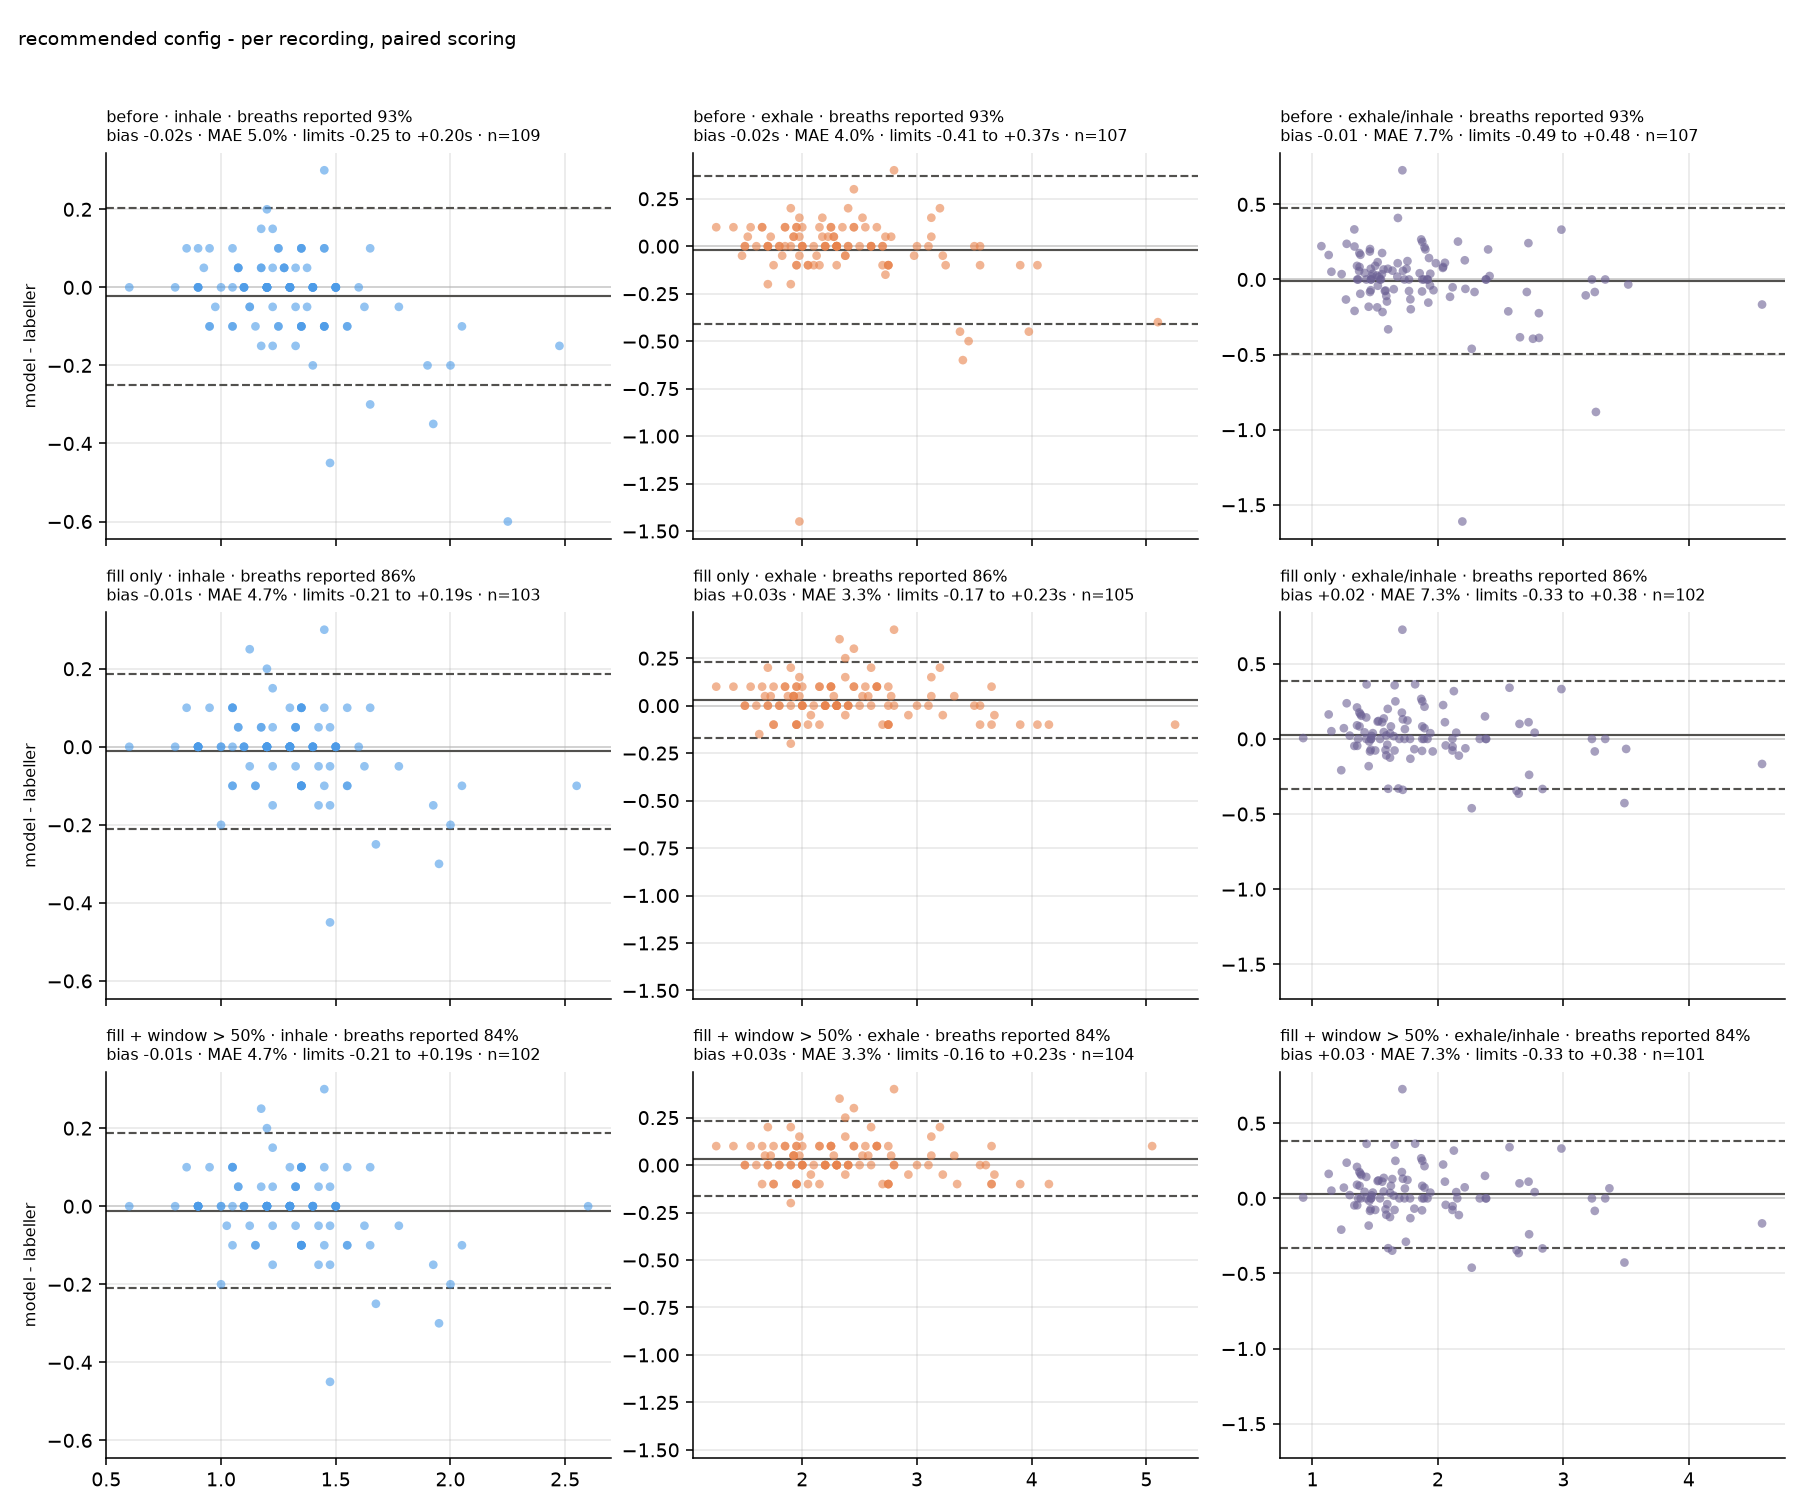

In [15]:
import matplotlib.pyplot as plt

TINT = {'inhale': PLOT['phase_colors']['inhale'], 'exhale': PLOT['phase_colors']['exhale'],
        durations.RATIO: figures.DERIVED_COLOR}


def before_after(name: str, results: dict) -> Path:
    fig, axes = plt.subplots(len(results), len(COLUMNS), figsize=(4.3 * len(COLUMNS), 3.6 * len(results)),
                             sharey='col', sharex='col', squeeze=False)
    for r, (label, kept) in enumerate(results.items()):
        medians = durations.signal_medians(kept)
        stats = durations.signal_agreement(medians, COLUMNS)
        usable = medians[medians[durations.USABLE]]
        for c, phase in enumerate(COLUMNS):
            ax, row = axes[r][c], stats.loc[phase]
            picked = usable[usable.phase == phase].dropna(subset=['median_labelled', 'median_model'])
            figures._bland_altman(ax, picked['median_labelled'].to_numpy(float),
                                  picked['median_model'].to_numpy(float), row, TINT[phase])
            unit = '' if phase == durations.RATIO else 's'
            ax.set_title(f"{label} · {phase} · breaths reported {labelled_breaths(kept) / ALL:.0%}\n"
                         f"bias {row['bias_sec']:+.2f}{unit} · MAE {row['relative_mae']:.1%} · limits "
                         f"{row['loa_low']:+.2f} to {row['loa_high']:+.2f}{unit} · n={int(row['n'])}",
                         fontsize=8, loc='left')
            ax.grid(alpha=0.3)
            for side in ('top', 'right'):
                ax.spines[side].set_visible(False)
        axes[r][0].set_ylabel('model - labeller', fontsize=8)
    fig.suptitle(f'{name} - per recording, paired scoring', fontsize=10, x=0.01, ha='left')
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    path = OUT / f"bland_altman_{name.replace(' ', '_').replace(',', '').replace('.', '')}.png"
    fig.savefig(path, dpi=140)
    plt.close(fig)
    return path


display(Image(filename=str(before_after('recommended config', steps))))

## The other configs, same rules and scoring

All scored against one reference - the merged labels with no correction - so a model trained on
blanked labels is not graded on its own easier target. `3-class, first run` is the recommended
config before augmentation was seeded: the gap between it and the control is run-to-run noise.

In [16]:
RUNS = {'control (recommended)': CONTROL,
        '3-class, first run': RUN,
        'blank_edge_spans': REPO / 'outputs/2026-09-27/12-26-42',
        'all_unknown_above 0.5': REPO / 'outputs/2026-09-27/12-53-43'}
REFERENCE = [truth for _, truth in control_windows]


def run_items(runs: Path) -> list[dict]:
    run_folds = rf.load_run(runs)
    run_settings = rf.settings_of(runs, run_folds, None, None)
    run_ensemble, run_windows = rf.ensemble_of(run_folds)
    assert np.array_equal(run_ensemble['window_id'], control_ensemble['window_id'])
    common = [(logits, truth) for (logits, _), truth in zip(run_windows, REFERENCE)]
    return rf.duration_items(runs, run_ensemble, common, run_settings['cost'],
                             run_settings['min_duration'])


across = {}
for name, runs in RUNS.items():
    run_rows = run_items(runs)
    across[(name, 'before')] = summary(under_rules(run_rows, None, fill=False))
    across[(name, 'after')] = summary(under_rules(run_rows, T))
pd.DataFrame(across).T

5 folds, 228 test windows each, 15 patients - window ids identical
labels.source = human, stop_as_exhale = True, switch_penalty = 2.0, enforce_min = False, transition table = {'unknown': ['inhale', 'exhale'], 'inhale': ['exhale', 'unknown'], 'exhale': ['inhale', 'unknown']}


5 folds, 228 test windows each, 15 patients - window ids identical
labels.source = human, stop_as_exhale = True, switch_penalty = 2.0, enforce_min = False, transition table = {'unknown': ['inhale', 'exhale'], 'inhale': ['exhale', 'unknown'], 'exhale': ['inhale', 'unknown']}


5 folds, 228 test windows each, 15 patients - window ids identical
labels.source = human, stop_as_exhale = True, switch_penalty = 2.0, enforce_min = False, transition table = {'unknown': ['inhale', 'exhale'], 'inhale': ['exhale', 'unknown'], 'exhale': ['inhale', 'unknown']}


5 folds, 228 test windows each, 15 patients - window ids identical
labels.source = human, stop_as_exhale = True, switch_penalty = 2.0, enforce_min = False, transition table = {'unknown': ['inhale', 'exhale'], 'inhale': ['exhale', 'unknown'], 'exhale': ['inhale', 'unknown']}


inhale                      \
                             breaths reported      n      bias     MAE %   
control (recommended) before         0.925067  109.0 -0.022936  5.021572   
                      after          0.839892  102.0 -0.011275  4.667094   
3-class, first run    before         0.931536  109.0  0.008257  4.899523   
                      after          0.847978  102.0  0.014216  4.769536   
blank_edge_spans      before         0.897574  109.0 -0.000917  4.205796   
                      after          0.661456   90.0  0.002778  4.286112   
all_unknown_above 0.5 before         0.913208  106.0   0.00283   4.62154   
                      after          0.839892  100.0    0.0115  4.598222   

                                             exhale                      \
                                      limits      n      bias     MAE %   
control (recommended) before  -0.25 to +0.20  107.0 -0.019626  3.998154   
                      after   -0.21 to +0.19  104.0  0.032692  3.322631   
3-class, first run    before  -0.19 to +0.20  108.0 -0.046296  4.353183   
                      after   -0.17 to +0.20  105.0  0.001429  3.097574   
blank_edge_spans      before  -0.20 to +0.20  106.0 -0.027358  3.136981   
                      after   -0.16 to +0.17   96.0 -0.000521  2.615002   
all_unknown_above 0.5 before  -0.18 to +0.19  108.0 -0.021759  3.701005   
                      after   -0.17 to +0.19  102.0  0.012745  2.925275   

                                             exhale/inhale            \
                                      limits             n      bias   
control (recommended) before  -0.41 to +0.37         107.0 -0.007816   
                      after   -0.16 to +0.23         101.0   0.02723   
3-class, first run    before  -0.48 to +0.39         108.0 -0.062444   
                      after   -0.20 to +0.20         102.0 -0.027203   
blank_edge_spans      before  -0.23 to +0.18         106.0 -0.037319   
                      after   -0.18 to +0.17          89.0 -0.014612   
all_unknown_above 0.5 before  -0.28 to +0.23         106.0 -0.028323   
                      after   -0.19 to +0.21         100.0 -0.015532   

                                                        
                                 MAE %          limits  
control (recommended) before  7.710472  -0.49 to +0.48  
                      after    7.28007  -0.33 to +0.38  
3-class, first run    before  8.065243  -0.56 to +0.43  
                      after   7.035948  -0.40 to +0.35  
blank_edge_spans      before  6.683088  -0.38 to +0.31  
                      after   6.190391  -0.32 to +0.29  
all_unknown_above 0.5 before  7.217406  -0.40 to +0.34  
                      after   6.953792  -0.36 to +0.33